In [19]:
import pandas as pd
import numpy as np

In [20]:
import pandas as pd
sales=pd.read_csv('https://raw.githubusercontent.com/tkseneee/Dataset/master/k_circle_sales.csv')

In [21]:
cat_data = sales.select_dtypes(include='str')
num_data = sales.select_dtypes(exclude='str')

In [22]:
sales.isnull().sum()

Item_Identifier                 0
Item_Weight                   749
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [ ]:
# Outlier Treatment
# Dropping Approach
# Capping if you have medium outliers are there
# Transformation if it has less outliers

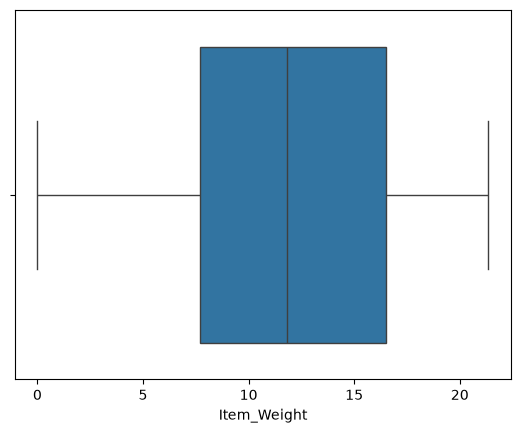

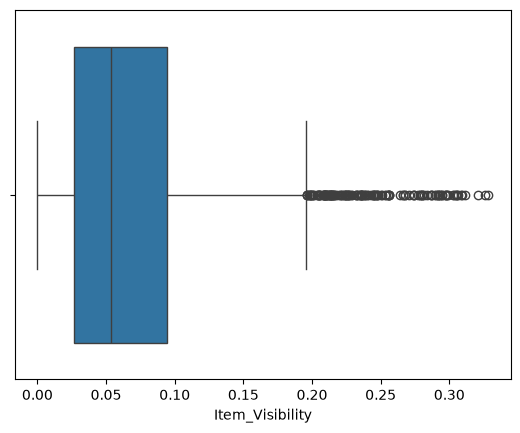

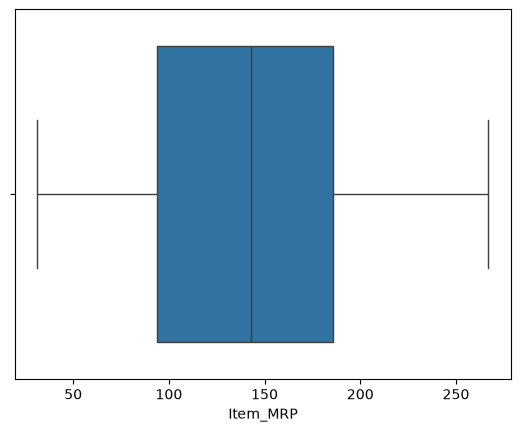

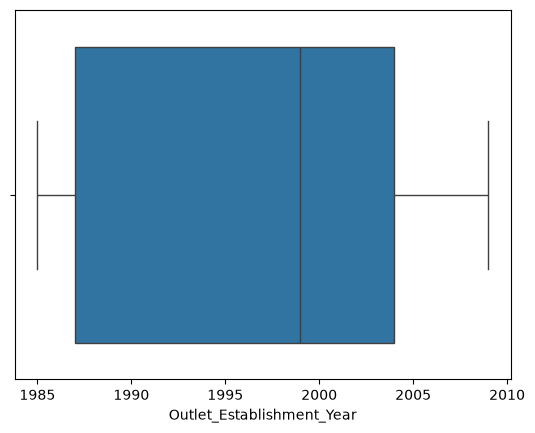

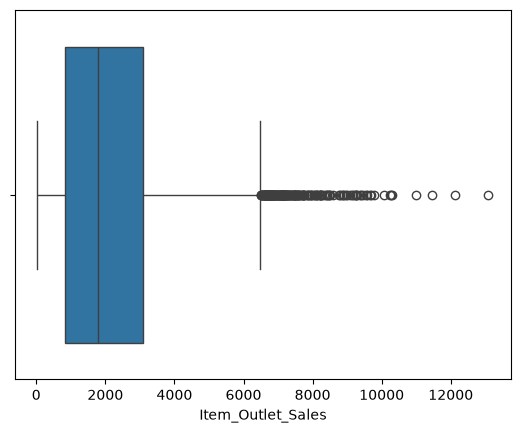

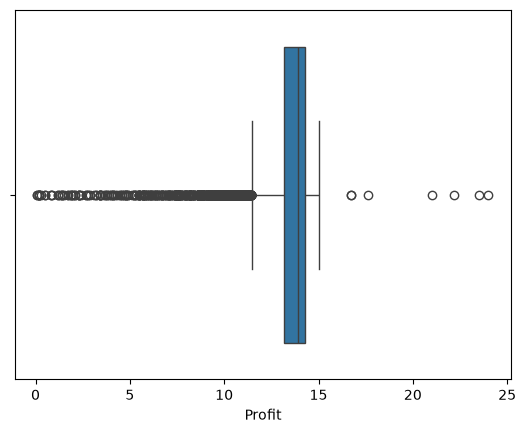

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

for i in num_data.columns:
               sns.boxplot(x=sales[i])
               plt.show()

In [25]:
# IQR 

for i in num_data.columns:
               q1 = sales[i].quantile(.25)
               q3 = sales[i].quantile(.75)
               iqr = q3-q1
               
               upper = 1.5*iqr+q3
               lower = q1-1.5*iqr
               
               outliers = sales[(sales[i]>upper) | (sales[i]<lower)].index
               print(f"The outliers present in the {i} data is ",len(outliers)/len(sales)*100)

The outliers present in the Item_Weight data is  0.0
The outliers present in the Item_Visibility data is  1.689545934530095
The outliers present in the Item_MRP data is  0.0
The outliers present in the Outlet_Establishment_Year data is  0.0
The outliers present in the Item_Outlet_Sales data is  2.1823301654347063
The outliers present in the Profit data is  8.271735304470257


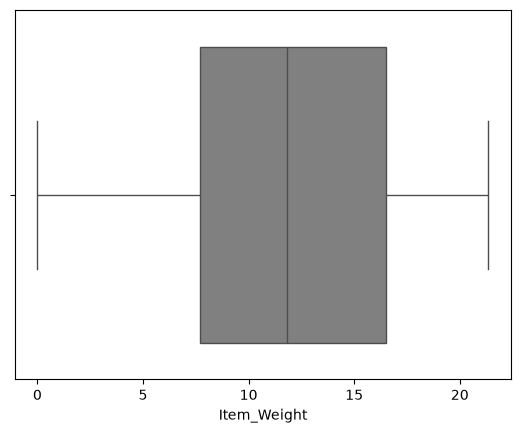

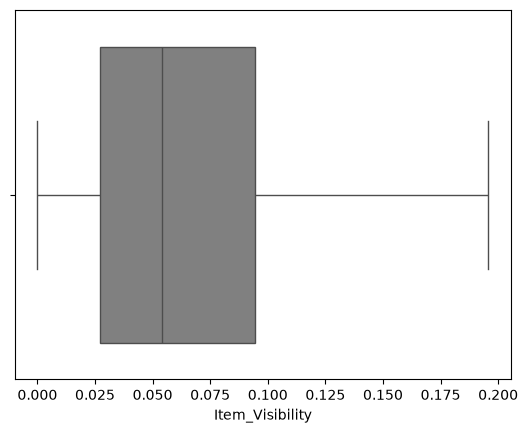

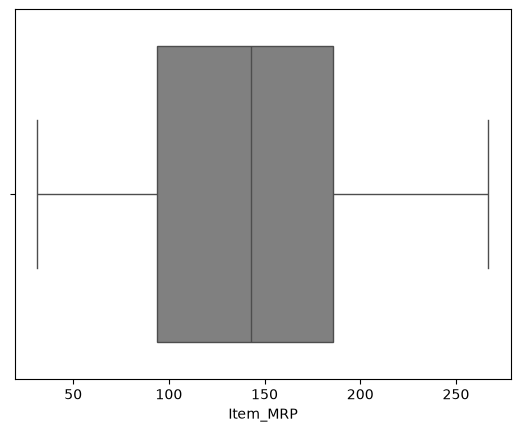

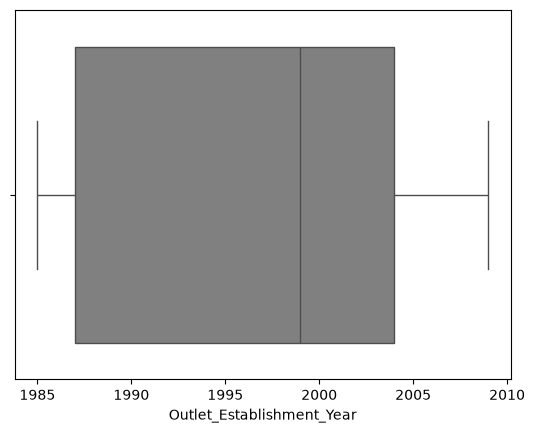

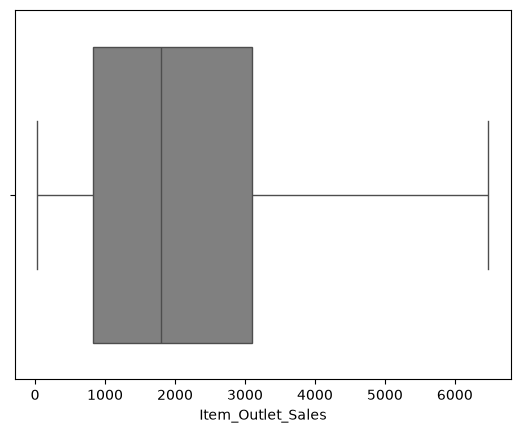

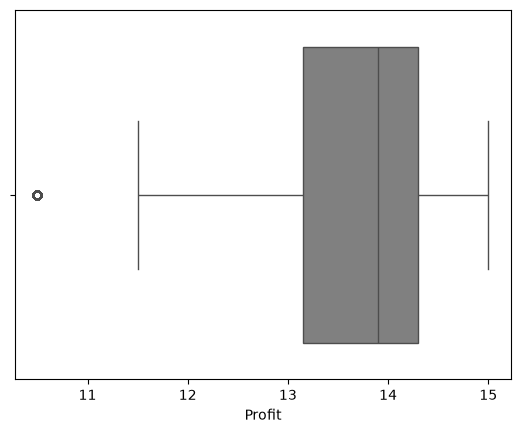

In [26]:
# Capping Approach
for i in num_data.columns:
               q1 = sales[i].quantile(.25)
               q3 = sales[i].quantile(.75)
               iqr = q3-q1
               
               upper = 1.5*iqr+q3
               lower = q1-1.5*iqr
               
               uc = sales[i].quantile(.95)
               lc = sales[i].quantile(.05)
               
               ind1 = sales[sales[i]>upper].index
               ind2 = sales[sales[i]<lower].index
               
               sales.loc[ind1,i]=uc
               sales.loc[ind2,i]=lc
               
               sns.boxplot(x=sales[i],color='grey')
               plt.show()

In [27]:
# IQR 

for i in num_data.columns:
               q1 = sales[i].quantile(.25)
               q3 = sales[i].quantile(.75)
               iqr = q3-q1
               
               upper = 1.5*iqr+q3
               lower = q1-1.5*iqr
               
               outliers = sales[(sales[i]>upper) | (sales[i]<lower)].index
               print(f"The outliers present in the {i} data is ",len(outliers)/len(sales)*100)

The outliers present in the Item_Weight data is  0.0
The outliers present in the Item_Visibility data is  0.0
The outliers present in the Item_MRP data is  0.0
The outliers present in the Outlet_Establishment_Year data is  0.0
The outliers present in the Item_Outlet_Sales data is  0.0
The outliers present in the Profit data is  8.18960459931949


In [28]:

for i in num_data.columns:
               q1 = sales[i].quantile(.25)
               q3 = sales[i].quantile(.75)
               iqr = q3-q1
               
               upper = 1.5*iqr+q3
               lower = q1-1.5*iqr
               
               outliers = sales[~(sales[i]>upper) | (sales[i]<lower)].index
               print(f"The outliers present in the {i} data is ",len(outliers)/len(sales)*100)

The outliers present in the Item_Weight data is  100.0
The outliers present in the Item_Visibility data is  100.0
The outliers present in the Item_MRP data is  100.0
The outliers present in the Outlet_Establishment_Year data is  100.0
The outliers present in the Item_Outlet_Sales data is  100.0
The outliers present in the Profit data is  100.0


In [32]:
# Transformation Approach

# log -- The data should be strictly positive

num_data.skew()

Item_Weight                 -0.352215
Item_Visibility              1.167091
Item_MRP                     0.127390
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
Profit                      -3.379808
dtype: float64

In [34]:
np.log(num_data['Item_Outlet_Sales']).skew()

np.float64(-0.8877533432093023)

In [ ]:
# Square root transformation
(num_data['Item_Outlet_Sales']**.5).skew()

np.float64(0.23467599347099247)

In [39]:
# left skewed / negative values
np.power(num_data['Profit'],3).skew()

np.float64(-0.04421105835966667)

<Axes: ylabel='Density'>

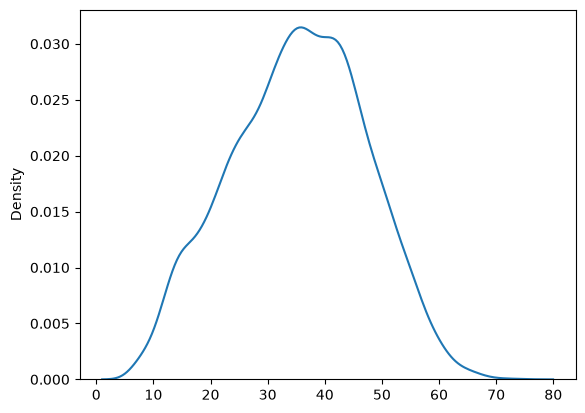

In [40]:
# Box Cox

from scipy.stats import boxcox

data, la=boxcox(num_data['Item_Outlet_Sales'])
sns.kdeplot(data)

In [41]:
data

array([47.00788035, 20.958293  , 37.96488976, ..., 30.71278698,
       36.19502283, 25.92628485], shape=(8523,))

In [ ]:
# Encoding :- converting string data to numerical data
cat_data

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 2,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 2,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 2,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,NaN,NaN,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...
8518,FDF22,Low Fat,Snack Foods,OUT013,High,Tier 3,Supermarket Type1
8519,FDS36,Regular,Baking Goods,OUT045,NaN,NaN,Supermarket Type1
8520,NCJ29,Low Fat,Health and Hygiene,OUT035,Small,Tier1,Supermarket Type1
8521,FDN46,Regular,Snack Foods,OUT018,Medium,Tier 2,Supermarket Type2


In [43]:
sales['Item_Fat_Content'].replace({'Low Fat':0,'Regular':1})

0       0
1       1
2       0
3       1
4       0
       ..
8518    0
8519    1
8520    0
8521    1
8522    0
Name: Item_Fat_Content, Length: 8523, dtype: object

In [44]:
# Ordinal Encoding
sales['Outlet_Size'].replace({'Small':0,"Medium":1,"High":2})

0         1
1         1
2         1
3       NaN
4         2
       ... 
8518      2
8519    NaN
8520      0
8521      1
8522      0
Name: Outlet_Size, Length: 8523, dtype: object

In [47]:
sales['Item_MRP'].quantile([0,.25,.50,.75,1])

0.00     31.30
0.25     93.80
0.50    142.70
0.75    185.65
1.00    266.90
Name: Item_MRP, dtype: float64

In [49]:
# binning

pd.cut(sales['Item_MRP'],
       bins=[31,94,187,267],
       labels=['Lowest',"Medium","Expensive"])

0       Expensive
1          Lowest
2          Medium
3          Medium
4          Lowest
          ...    
8518    Expensive
8519       Medium
8520       Lowest
8521       Medium
8522       Lowest
Name: Item_MRP, Length: 8523, dtype: category
Categories (3, str): ['Lowest' < 'Medium' < 'Expensive']

In [51]:
pd.qcut(sales['Item_MRP'],
       q=3,
       labels=['Lowest',"Medium","Expensive"])

0       Expensive
1          Lowest
2          Medium
3       Expensive
4          Lowest
          ...    
8518    Expensive
8519       Medium
8520       Lowest
8521       Lowest
8522       Lowest
Name: Item_MRP, Length: 8523, dtype: category
Categories (3, str): ['Lowest' < 'Medium' < 'Expensive']